#  Rigid Body Controll


---

E/20/395
--A.P Thilakarathna

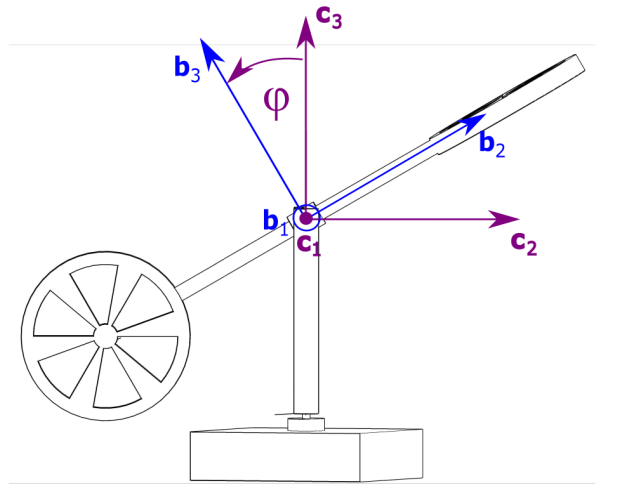

Figure 1-Intermidat cordinate system ans boady cordinate syastem

# System Configuration

Let the inertial frame be denoted by $\mathbf{e}$, and assume that it is fixed to body part A. The origin of this frame is taken as $O$.  
Now define another orthonormal frame $\mathbf{c}$, which is attached to body part C. This frame rotates with respect to $\mathbf{e}$ in such a way that the third axis remains common, i.e. $\mathbf{c}_3 \equiv \mathbf{e}_3$.

Therefore,

$$
\mathbf{c} = \mathbf{e}R_3(\theta)
$$

where

$$
R_3(\theta)=
\begin{bmatrix}
\cos\theta & -\sin\theta & 0\\
\sin\theta & \cos\theta & 0\\
0 & 0 & 1
\end{bmatrix}.
$$

Next, consider another orthonormal frame $\mathbf{b}$, which is fixed to body part B. This frame moves relative to $\mathbf{c}$ such that its first axis remains aligned with the first axis of $\mathbf{c}$, i.e. $\mathbf{b}_1 \equiv \mathbf{c}_1$.

Hence,

$$
\mathbf{b} = \mathbf{c}R_1(\phi)
$$

where

$$
R_1(\phi)=
\begin{bmatrix}
1 & 0 & 0\\
0 & \cos\phi & -\sin\phi\\
0 & \sin\phi & \cos\phi
\end{bmatrix}.
$$

The origins of the $\mathbf{e}$-frame and $\mathbf{c}$-frame are assumed to coincide. Taking point B as the origin of the $\mathbf{b}$-frame, the orientation of $\mathbf{b}$ with respect to $\mathbf{e}$ can be written as

$$
\mathbf{b}=\mathbf{e}R_3(\theta)R_1(\phi)=\mathbf{e}R.
$$

Therefore,

$$
R = R_3(\theta)R_1(\phi).
$$

Differentiating the rotation matrix gives

$$
\dot{R}
=
\dot{R}_3R_1+R_3\dot{R}_1.
$$

Using the angular velocity matrices,

$$
\dot{R}
=
R_3\widehat{\Omega}_3R_1
+
R_3R_1\widehat{\Omega}_1
=
R\widehat{\Omega}.
$$

Thus,

$$
\widehat{\Omega}
=
R_1^T\widehat{\Omega}_3R_1
+
\widehat{\Omega}_1.
$$

Therefore, the angular velocity vector becomes

$$
\Omega
=
\dot{\theta}R_1^T(\phi)e_3
+
\dot{\phi}e_1.
$$

Hence,

$$
\Omega
=
\begin{bmatrix}
\dot{\phi}\\
\dot{\theta}\sin\phi\\
\dot{\theta}\cos\phi
\end{bmatrix}.
$$

The body-frame angular momentum is

$$
\Pi = \mathbb{I}\Omega,
$$

where $\mathbb{I}$ is the inertia matrix.

The same angular momentum expressed in the inertial frame is

$$
\pi = R\Pi = R\mathbb{I}\Omega.
$$

# The Constraint Moment

The constraint moment acting on the system prevents rotation about the $\mathbf{b}_2$ direction. Therefore, the constraint moment can be written as

$$
\tau_c
=
R
\begin{bmatrix}
0\\
T_2\\
0
\end{bmatrix}.
$$

Here, $T_2$ is the unknown constraint moment along the second body axis.

# The Actuation Moments

The actuator moments can be expressed in the body frame as

$$
T_u
=
\begin{bmatrix}
u_1\cos\alpha-u_2\cos\beta\\
0\\
u_1\sin\alpha-u_2\sin\beta
\end{bmatrix}.
$$

Therefore, in the inertial frame,

$$
\tau_u
=
RT_u
=
R
\begin{bmatrix}
u_1\cos\alpha-u_2\cos\beta\\
0\\
u_1\sin\alpha-u_2\sin\beta
\end{bmatrix}.
$$

For the control input to be implementable, it must not produce a component along the constrained direction. Hence,

$$
T_u^T e_2 = 0.
$$

The actuator moment can also be written in matrix form as

$$
\tau_u
=
R
\begin{bmatrix}
1 & 0\\
0 & 0\\
0 & 1
\end{bmatrix}
\begin{bmatrix}
\cos\alpha & -\cos\beta\\
\sin\alpha & -\sin\beta
\end{bmatrix}
\begin{bmatrix}
u_1\\
u_2
\end{bmatrix}.
$$

# Equations of Motion

The kinematic equation is

$$
\dot{R}=\widehat{\omega}R.
$$

The angular momentum in the inertial frame is

$$
\pi = R\mathbb{I}R^T\omega.
$$

The rotational equation of motion is

$$
\dot{\pi}=\tau_u+\tau_c.
$$

Since

$$
\tau_u = RT_u,
$$

the equation of motion can also be written as

$$
\dot{\pi}=RT_u+\tau_c.
$$

Now, the constraint moment component can be obtained by projecting the equation along the constrained body direction:

$$
T_2 = e_2^T R^T\dot{\pi}.
$$

Using the body-frame angular velocity expression,

$$
T_2
=
e_2^T
\left(
\Omega \times \mathbb{I}\Omega
+
\mathbb{I}\dot{\Omega}
\right).
$$

Therefore, the constraint moment is determined from the second component of the body-frame rotational dynamics.

## Derivation of $\dot{E}$

The tracking error is defined as

$$
E = R_r^T R
$$

Differentiate both sides with respect to time:

$$
\dot{E} = \frac{d}{dt}(R_r^T R)
       = \dot{R}_r^T R + R_r^T \dot{R}
$$

Using the kinematics of the actual and reference rotations,

$$
\dot{R} = R \hat{\Omega}
\qquad\text{and}\qquad
\dot{R}_r = R_r \hat{\Omega}_r
$$

substitute into the above equation.

First,

$$
R_r^T \dot{R} = R_r^T R \hat{\Omega} = E \hat{\Omega}
$$

Next,

$$
\dot{R}_r^T = (R_r \hat{\Omega}_r)^T
$$

Using $(AB)^T = B^T A^T$ and $\hat{\Omega}_r^T = -\hat{\Omega}_r$,

$$
\dot{R}_r^T = \hat{\Omega}_r^T R_r^T = -\hat{\Omega}_r R_r^T
$$

Therefore,

$$
\dot{R}_r^T R = -\hat{\Omega}_r R_r^T R = -\hat{\Omega}_r E
$$

So,

$$
\dot{E} = -\hat{\Omega}_r E + E \hat{\Omega}
$$

Now use the identity

$$
\widehat{E^T \Omega_r} = E^T \hat{\Omega}_r E
$$

which gives

$$
E \widehat{E^T \Omega_r} = E E^T \hat{\Omega}_r E = \hat{\Omega}_r E
$$

Substitute this into the previous result:

$$
\dot{E} = E \hat{\Omega} - E \widehat{E^T \Omega_r}
$$

Factor out $E$:

$$
\dot{E} = E \left( \hat{\Omega} - \widehat{E^T \Omega_r} \right)
$$

Since the hat map is linear,

$$
\hat{\Omega} - \widehat{E^T \Omega_r}
= \widehat{\Omega - E^T \Omega_r}
$$

Hence, the final result is

$$
\boxed{
\dot{E} = E\,\widehat{(\Omega - E^T \Omega_r)}
}
$$

where

$$
\Omega_E = \Omega - E^T \Omega_r
$$

is called the **velocity error**.

$$
V(E)=\frac{k_p}{2}\,\operatorname{trace}\!\left(K(I-E)\right)
$$

# Intrinsic PD on SO(3)

## Reference trajectory

The reference attitude is the desired rotation \(R_r(t)\). Its motion is written as

$$
\dot R_r = R_r \widehat{\Omega_r(t)}.
$$

This means the desired rotation changes with the desired angular velocity \(\Omega_r(t)\). The hat symbol converts the angular velocity vector into a skew-symmetric matrix so it can be used in the rotation-matrix equation.



## Tracking error

The attitude tracking error is defined as

$$
E = R_r^T R.
$$

This compares the actual attitude \(R\) with the desired attitude \(R_r\). If \(E=I\), then the actual and desired attitudes are exactly the same. Since \(E\) is also a rotation matrix, the error is described directly on \(SO(3)\), not by subtracting Euler angles.



## Velocity error

The slides write

$$
\dot E = E\,\widehat{(\Omega - E^T\Omega_r)}
$$

and define

$$
\Omega_E = \Omega - E^T\Omega_r.
$$

This is the angular velocity error. Here, \(\Omega\) is the actual angular velocity in the current body frame, while \(\Omega_r\) is the reference angular velocity in the reference frame. So \(E^T\Omega_r\) is used to express the reference angular velocity in the current body frame before subtracting it from \(\Omega\).



## Potential function on \(SO(3)\)

The potential function is defined as

$$
V(E)=\frac{k_p}{2}\operatorname{trace}(K(I-E)).
$$

This is the attitude error energy. It plays the same role as the quadratic position-error term in ordinary PD control. When the attitude error is large, \(V(E)\) is large. When the attitude error goes to zero, \(V(E)\) reaches its minimum.

---

## Why \(K\) is used

The matrix \(K\) is chosen as

$$
K=\operatorname{diag}\{I_2+I_3-I_1,\; I_3+I_1-I_2,\; I_1+I_2-I_3\}.
$$

This matrix is built from the principal moments of inertia \(I_1\), \(I_2\), and \(I_3\). Its purpose is to weight the attitude error according to the rigid body inertia. So the controller does not treat all axes equally; it includes the physical properties of the body in the error measure.



## Axis-angle form of the error

The error matrix is written as

$$
E = I + \sin\theta_e\,\widehat n_e + (1-\cos\theta_e)\widehat n_e^2.
$$

This is the Rodrigues formula. It says that the error rotation \(E\) can be represented by a rotation of angle \(\theta_e\) about a unit axis \(n_e\). So instead of thinking of error as three separate angles, the error is described as one rotation about one axis.



## Simplified form of the potential

Using the axis-angle form, the potential becomes

$$
V(E)=\alpha_n\frac{k_p}{2}(1-\cos\theta_e)\ge 0,
$$

where

$$
\alpha_n = I_1n_{e1}^2 + I_2n_{e2}^2 + I_3n_{e3}^2.
$$

This shows that the potential depends on the error angle \(\theta_e\) and also on the body inertia through \(\alpha_n\). Since \(1-\cos\theta_e\ge 0\), the potential is always nonnegative.



## How the three maxima are found

To find the three maxima, start from

$$
V(E)=\alpha_n\frac{k_p}{2}(1-\cos\theta_e).
$$

Since \(k_p>0\) and \(\alpha_n>0\), the maximum value of \(V(E)\) happens when

$$
1-\cos\theta_e
$$

is largest. This happens at

$$
\theta_e=\pi,
$$

which means a 180-degree rotation error. Now use the Rodrigues formula:

$$
E = I + \sin\theta_e\,\widehat n_e + (1-\cos\theta_e)\widehat n_e^2.
$$

For \(\theta_e=\pi\),

$$
\sin\pi=0,\qquad \cos\pi=-1,
$$

so

$$
E = I + 2\widehat n_e^2.
$$

Using the identity

$$
\widehat n_e^2 = n_e n_e^T - I,
$$

we get

$$
E = 2n_e n_e^T - I.
$$

Now choose the principal axes one by one.

If

$$
n_e=e_1=\begin{bmatrix}1\\0\\0\end{bmatrix},
$$

then

$$
E=\operatorname{diag}(1,-1,-1).
$$

If

$$
n_e=e_2=\begin{bmatrix}0\\1\\0\end{bmatrix},
$$

then

$$
E=\operatorname{diag}(-1,1,-1).
$$

If

$$
n_e=e_3=\begin{bmatrix}0\\0\\1\end{bmatrix},
$$

then

$$
E=\operatorname{diag}(-1,-1,1).
$$

These are the three special 180-degree error attitudes shown in the slides.



## Unique minimum and the three bad points

The slides say that the potential has a unique minimum at

$$
E=I_{3\times3},
$$

and three maxima at

$$
E=\operatorname{diag}(1,-1,-1),\quad
E=\operatorname{diag}(-1,1,-1),\quad
E=\operatorname{diag}(-1,-1,1).
$$

So the desired attitude corresponds to the unique minimum, while the three 180-degree flip attitudes are the undesired critical points. This is why the controller is almost globally stable, not globally stable.


## Gradient of the potential

The slides then define

$$
\nabla V \triangleq \zeta_E.
$$

This \(\zeta_E\) is the gradient of the potential. It gives the direction in which the controller should act to reduce the attitude error. In simple words, \(V(E)\) tells how much error exists, and \(\zeta_E\) tells which way to move to reduce it.


## Lyapunov function

The Lyapunov function is written as

$$
W(E,\Omega_E)=V(E)+\frac12\langle I\Omega_E,\Omega_E\rangle \ge 0.
$$

This contains two parts: the potential energy from the attitude error and the kinetic-energy-like term from the velocity error. So it measures both orientation mismatch and angular velocity mismatch.



## Error dynamics in angular velocity

The slides derive the error angular velocity dynamics as

$$
I\dot\Omega_E = I\Omega_E\times\Omega_E + T^u - F_r(E,\Omega_E,\Omega_r).
$$

Here, \(T^u\) is the control torque, and \(F_r\) is the reference-related feedforward term that appears because the reference is moving. This equation is the rotational version of the error dynamics used in ordinary PD control.



## Time derivative of the Lyapunov function

The slides show that

$$
\frac{d}{dt}W(E,\Omega_E)
=
\left\langle k_p I\zeta_E + T^u - F_r,\; \Omega_E \right\rangle.
$$

This is the key step in the stability proof. It tells how the total error energy changes with time. The goal is to choose the control torque so that this derivative becomes nonpositive.



## Intrinsic PD control law

The control law is chosen as

$$
T^u = -I(k_p\zeta_E + k_d\Omega_E) + F_r.
$$

This contains a proportional term, a derivative term, and the feedforward/reference compensation term. After substituting this into the derivative of the Lyapunov function, the slides get

$$
\frac{d}{dt}W(E,\Omega_E)
=
-k_d\langle I\Omega_E,\Omega_E\rangle \le 0.
$$

So the total error energy never increases.



## Final stability result

Using LaSalle’s invariance principle, the slides conclude that

$$
\lim_{t\to\infty}R(t)=R_r(t)
$$

for all initial conditions except the three special maxima. So the controller drives the actual attitude to the desired attitude for almost all initial conditions.



## Intrinsic PID extension

The last slide extends the PD controller to PID by adding an integral term. The control law becomes

$$
T^u = -I(k_p\zeta_E + k_d\Omega_E + k_I\Omega_I),
$$

with a geometrically defined integral error \(\Omega_I\). The slides note that this intrinsic PID form works even for problems with singular inertia tensors.

# Controller

In this section, the objective is to study how a rigid body can follow a desired smooth reference trajectory  
$R_r(t) \in \mathbb{R}^3 \times SO(3)$ asymptotically.




The configuration space $SO(3)$ forms a group. Therefore, the attitude error between the actual configuration  
$R \in \mathbb{R}^3 \times SO(3)$ and the desired reference configuration  
$R_r \in \mathbb{R}^3 \times SO(3)$ can be defined globally.

One possible definition is

$$
R_e \triangleq R^{-1}R_r \in SO(3),
$$

or alternatively,

$$
R_e \triangleq R_rR^{-1} \in SO(3).
$$

The first expression is known as the **left-invariant error**, while the second expression is known as the  
**right-invariant error**.

Both error definitions remain inside the configuration space $SO(3)$, rather than being defined in the spatial momentum space.



Let $R_r(t)$ be the desired attitude trajectory, and let $\omega_r(t)$ satisfy

$$
\widehat{\omega}_r(t)=\dot{R}_rR_r^T.
$$

The reference spatial angular momentum is defined as

$$
\pi_r \triangleq R_r \mathbb{I} R_r^T \omega_r.
$$

Now define the configuration error as

$$
R_e = R_rR^T.
$$

The spatial angular velocity of the tracking error is

$$
\widehat{\omega}_e \triangleq \dot{R}_eR_e^T.
$$

Using the definition of $R_e$, this becomes

$$
\widehat{\omega}_e
=
\widehat{\omega}_r(t)-R_e\widehat{\omega}(t)R_e^T.
$$

Therefore,

$$
\omega_e=\omega_r-R_e\omega.
$$

The angular momentum error is defined as

$$
\pi_e \triangleq R\mathbb{I}R_r^T\omega_e.
$$

Substituting $\omega_e$ gives

$$
\pi_e
=
R\mathbb{I}R_r^T(\omega_r-R_e\omega).
$$

Hence,

$$
\pi_e
=
R\mathbb{I}R_r^T\omega_r
-
R\mathbb{I}R^T\omega.
$$

Since $\pi=R\mathbb{I}R^T\omega$, we obtain

$$
\pi_e=R_e^T\pi_r-\pi.
$$

Differentiating the momentum error gives

$$
\dot{\pi}_e
=
R_e^T(\dot{\pi}_r-\omega_e\times \pi_r)-\dot{\pi}.
$$

This can also be written as

$$
\dot{\pi}_e
=
R_e^T
\left(
R_r\dot{\Pi}_r+(\omega_r-\omega_e)\times \pi_r
\right)
-
\dot{\pi}.
$$

Therefore,

$$
\dot{\pi}_e
=
(R\dot{\Pi}_r+\omega\times \pi_r)-\dot{\pi}.
$$

Thus, the tracking error dynamics are

$$
\dot{R}_e=\widehat{\omega}_eR_e,
$$

and

$$
\dot{\pi}_e
=
(R\dot{\Pi}_r+\omega\times \pi_r)-\tau_u-\tau_e.
$$


The integral error is introduced as

$$
\dot{e}_{I_R}=e_R.
$$

The control torque is selected as

$$
\tau_u
=
-\tau_e
+
(R\dot{\Pi}_r+\omega\times \pi_r)
+
k_{P_R}e_R
+
k_{D_R}\pi_e
+
k_{I_R}e_{I_R}.
$$

Substituting this control law into the error dynamics gives

$$
\dot{R}_e=\widehat{\omega}_eR_e,
$$

and

$$
\dot{\pi}_e
=
k_{P_R}e_R
+
k_{D_R}\pi_e
+
k_{I_R}e_{I_R}.
$$



Let

$$
K=\mathrm{diag}\{\mathbb{K}_1,\mathbb{K}_2,\mathbb{K}_3\},
$$

where $\mathbb{K}_1$, $\mathbb{K}_2$, and $\mathbb{K}_3$ are three different positive constants.

The attitude proportional error $e_R$ is obtained from

$$
\widehat{e}_R
=
\frac{1}{2}
\left(
R_eK-KR_e^T
\right).
$$

Here, $\widehat{e}_R$ is the skew-symmetric matrix corresponding to the vector $e_R$.



For implementation, the required quantities are $R_e$, $\pi_e$, and $e_R$.  
These can be computed using the measured variables

$$
\theta,\quad \phi,\quad \dot{\theta},\quad \dot{\phi}.
$$

The configuration error is

$$
R_e
=
R_rR^T.
$$

Using the rotation matrices,

$$
R_e
=
R_1(\phi_r)R_3(\theta_r)R_3^T(\theta)R_1^T(\phi).
$$

Therefore,

$$
R_e
=
R_1(\phi_r)R_3(\theta_r-\theta)R_1^T(\phi).
$$

The body angular velocity is written as

$$
\Omega
=
R_3^T(\theta)
\begin{bmatrix}
\dot{\phi}\\
0\\
0
\end{bmatrix}
+
\begin{bmatrix}
0\\
0\\
\dot{\theta}
\end{bmatrix}.
$$

The spatial angular momentum is

$$
\pi=R\mathbb{I}\Omega.
$$

The angular momentum error is

$$
\pi_e=R_e^T\pi_r-\pi.
$$

The PID control law becomes

$$
\dot{e}_{I_R}=e_R,
$$

and

$$
\tau_u
=
(R\dot{\Pi}_r+\omega\times \pi_r)
+
k_{P_R}e_R
+
k_{D_R}\pi_e
+
k_{I_R}e_{I_R}.
$$

The same control torque expressed in the body frame is

$$
T_u=R^T\tau_u.
$$

Therefore,

$$
T_u
=
(\dot{\Pi}_r+\Omega\times R^T\pi_r)
+
k_{P_R}R^Te_R
+
k_{D_R}(R_r^T\pi_r-\mathbb{I}\Omega)
+
k_{I_R}R^Te_{I_R}.
$$



Recall that the body-frame actuator torque is

$$
R^T\tau_u=T_u=
\begin{bmatrix}
u_1\cos\alpha-u_2\cos\beta\\
0\\
u_1\sin\alpha-u_2\sin\beta
\end{bmatrix}.
$$

For simplicity, take

$$
\beta=\alpha.
$$

Then,

$$
R^T\tau_u=T_u=
\begin{bmatrix}
(u_1-u_2)\cos\alpha\\
0\\
(u_1-u_2)\sin\alpha
\end{bmatrix}.
$$

Let

$$
u_- = u_1-u_2,
$$

and

$$
u_+ = u_1+u_2.
$$

Then the required actuator difference is obtained from the first and third components of $R^T\tau_u$:

$$
u_-
=
\sqrt{
\left(e_1^TR^T\tau_u\right)^2
+
\left(e_3^TR^T\tau_u\right)^2
}.
$$

The actuator angle is

$$
\tan(\alpha)
=
\frac{
e_3^TR^T\tau_u
}{
e_1^TR^T\tau_u
}.
$$

Equivalently,

$$
\alpha
=
\tan^{-1}
\left(
\frac{
e_3^TR^T\tau_u
}{
e_1^TR^T\tau_u
}
\right).
$$

In [ ]:
import numpy as np

def twin_rotor_inertia_matrix(y1, y2, m1, m2):
    """
    Compute simplified inertia matrix in b-frame for two motors
    placed on the b2 axis.

    Parameters
    ----------
    y1 : float
        Distance of motor 1 from pivot (m)
    y2 : float
        Distance of motor 2 from pivot (m)
    m1 : float
        Mass of motor 1 (kg)
    m2 : float
        Mass of motor 2 (kg)

    Returns
    -------
    numpy.ndarray
        3x3 inertia matrix
    """
    I_val = m1 * y1**2 + m2 * y2**2

    I_b = np.array([
        [I_val, 0.0,   0.0],
        [0.0,   0.0,   0.0],
        [0.0,   0.0, I_val]
    ])

    return I_b

In [ ]:
import numpy as np

def vee(S):
    """
    Convert a 3x3 skew-symmetric matrix S into a 3x1 vector.
    """
    return np.array([
        S[2, 1],
        S[0, 2],
        S[1, 0]
    ])

def compute_eR(Re, K):
    """
    Compute eR from:
        hat(eR) = 0.5 * (Re.T @ K - K @ Re)

    Parameters
    ----------
    Re : array-like, shape (3,3)
        Rotation error matrix
    K : array-like
        Either:
        - a length-3 list/tuple/array [K1, K2, K3], or
        - a 3x3 matrix

    Returns
    -------
    eR : ndarray, shape (3,)
        Error vector eR
    hat_eR : ndarray, shape (3,3)
        Skew-symmetric matrix hat(eR)
    """
    Re = np.asarray(Re, dtype=float)
    K = np.asarray(K, dtype=float)

    if Re.shape != (3, 3):
        raise ValueError("Re must be a 3x3 matrix.")

    # If K is given as [K1, K2, K3], convert to diagonal matrix
    if K.shape == (3,):
        K = np.diag(K)
    elif K.shape != (3, 3):
        raise ValueError("K must be either a length-3 vector or a 3x3 matrix.")

    # Compute hat(eR)
    hat_eR = 0.5 * (Re.T @ K - K @ Re)

    # Optional: force exact skew symmetry to reduce numerical error
    hat_eR = 0.5 * (hat_eR - hat_eR.T)

    # Convert to vector form
    eR = vee(hat_eR)

    return eR, hat_eR

In [ ]:
import numpy as np

def compute_Re(Rr, R):
    """
    Compute Re = Rr @ R.T

    Parameters
    ----------
    Rr : array-like, shape (3,3)
        Reference rotation matrix
    R : array-like, shape (3,3)
        Current rotation matrix

    Returns
    -------
    Re : ndarray, shape (3,3)
        Rotation error matrix
    """
    Rr = np.asarray(Rr, dtype=float)
    R = np.asarray(R, dtype=float)

    if Rr.shape != (3, 3):
        raise ValueError("Rr must be a 3x3 matrix.")
    if R.shape != (3, 3):
        raise ValueError("R must be a 3x3 matrix.")

    Re = Rr @ R.T
    return Re

Impimentation


In [ ]:
import numpy as np

def rotation_matrix_to_ypr_safe(R):
    """
    ZYX convention:
    R = Rz(yaw) @ Ry(pitch) @ Rx(roll)
    Returns yaw, pitch, roll in radians
    """
    r11, r12, r13 = R[0, 0], R[0, 1], R[0, 2]
    r21, r22, r23 = R[1, 0], R[1, 1], R[1, 2]
    r31, r32, r33 = R[2, 0], R[2, 1], R[2, 2]

    if abs(r31) < 1.0:
        pitch = np.arcsin(-r31)
        roll  = np.arctan2(r32, r33)
        yaw   = np.arctan2(r21, r11)
    else:
        # Gimbal lock
        pitch = np.pi / 2 if r31 <= -1 else -np.pi / 2
        roll = 0.0
        if r31 <= -1:
            yaw = np.arctan2(-r12, r22)
        else:
            yaw = np.arctan2(-r12, r22)

    return yaw, pitch, roll

In [ ]:
import numpy as np

def hat(omega):
    wx, wy, wz = omega
    return np.array([
        [0.0, -wz,  wy],
        [wz,   0.0, -wx],
        [-wy,  wx,   0.0]
    ])

def exp_so3(phi):
    theta = np.linalg.norm(phi)
    I = np.eye(3)

    if theta < 1e-12:
        return I + hat(phi)

    H = hat(phi)
    A = np.sin(theta) / theta
    B = (1 - np.cos(theta)) / (theta**2)

    return I + A * H + B * (H @ H)

def project_to_so3(R):
    U, _, Vt = np.linalg.svd(R)
    R_proj = U @ Vt
    if np.linalg.det(R_proj) < 0:
        U[:, -1] *= -1
        R_proj = U @ Vt
    return R_proj

def compute_R_from_Tu(Tu_array, dt):
    """
    Compute R from torque input Tu only.

    Assumptions:
        I = diag(1,1,1)
        R0 = identity
        Omega0 = [0,0,0]

    Parameters
    ----------
    Tu_array : ndarray of shape (N,3)
        Torque input at each time step
    dt : float
        Time step

    Returns
    -------
    R_hist : ndarray of shape (N,3,3)
        Rotation matrix history
    Omega_hist : ndarray of shape (N,3)
        Angular velocity history
    """
    N = len(Tu_array)

    R_hist = np.zeros((N, 3, 3))
    Omega_hist = np.zeros((N, 3))

    R = np.eye(3)                 # vertical initial attitude
    Omega = np.zeros(3)           # no initial motion

    R_hist[0] = R
    Omega_hist[0] = Omega

    for k in range(N - 1):
        Tu = Tu_array[k]

        # Since I = identity:
        # Omega_dot = Tu
        I = np.eye(3)

        Omega_dot = np.linalg.solve(I, np.cross(I @ Omega, Omega) + Tu)
        # if the first torque component is negative, flip Omega_dot[0]
        if Tu[0] < 0:
           Omega_dot[0] = -Omega_dot[0]
           Omega_next = Omega - dt * Omega_dot
        #print(Omega_dot)
        # update Omega
        else:
            Omega_next = Omega + dt * Omega_dot

        # use midpoint angular velocity for R update
        Omega_mid = 0.5 * (Omega + Omega_next)

        # update R
        R = R @ exp_so3(Omega_mid*dt)
        R = project_to_so3(R)

        Omega = Omega_next

        R_hist[k + 1] = R
        Omega_hist[k + 1] = Omega

    return R_hist, Omega_hist

In [ ]:


def omega_to_phi_theta_rates(Omega):
    phi_dot = Omega[0]
    theta_dot = np.sqrt(Omega[1]**2 + Omega[2]**2)  # when cos(phi) not near zero
    return phi_dot, theta_dot

In [ ]:
import numpy as np

def omega_to_phi_theta_rates(Omega):
    phi_dot = Omega[0]
    theta_dot = np.sqrt(Omega[1]**2 + Omega[2]**2)
    return phi_dot, theta_dot

dt = 0.01
T = 5.0
N = int(T / dt)

t = np.arange(N) * dt

Tu_array = np.zeros((N, 3))
# Tu_array[:, 0] = 0.5 * np.sin(2 * np.pi * 1.0 * t)
Tu_array[:, 0] = 0.5 * np.sin(2 * np.pi * 1.0 * t)

R_hist, Omega_hist = compute_R_from_Tu(Tu_array, dt)

print("R_hist =")
print(R_hist)

print("Omega_hist =")
print(Omega_hist)

phi_dot = np.zeros(N)
theta_dot = np.zeros(N)

for k in range(N):
    phi_dot[k], theta_dot[k] = omega_to_phi_theta_rates(Omega_hist[k])

# integrate to get phi and theta
phi = np.zeros(N)
theta = np.zeros(N)

for k in range(N - 1):
    phi[k + 1] = phi[k] + dt * phi_dot[k]
    theta[k + 1] = theta[k] + dt * theta_dot[k]

print("phi_dot =")
print(phi_dot)

print("theta_dot =")
print(theta_dot)

print("phi =")
print(phi)

print("theta =")
print(theta)

R_hist =
[[[ 1.00000000e+00  0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  1.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]

 [[ 1.00000000e+00  0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  1.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]

 [[ 1.00000000e+00  0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  1.00000000e+00 -1.56976299e-06]
  [ 0.00000000e+00  1.56976299e-06  1.00000000e+00]]

 ...

 [[ 1.00000000e+00  0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  9.21940851e-01 -3.87330696e-01]
  [ 0.00000000e+00  3.87330696e-01  9.21940851e-01]]

 [[ 1.00000000e+00  0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  9.21935393e-01 -3.87343687e-01]
  [ 0.00000000e+00  3.87343687e-01  9.21935393e-01]]

 [[ 1.00000000e+00  0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  9.21932963e-01 -3.87349470e-01]
  [ 0.00000000e+00  3.87349470e-01  9.21932963e-01]]]
Omega_hist =
[[0.         0.         

In [ ]:
import numpy as np
import plotly.graph_objects as go

# -----------------------------
# Simulation settings
# -----------------------------
dt = 1
N = 1000
t = np.arange(N) * dt
T = t[-1]



# -----------------------------
# Plot torque vs time
# Use Scattergl for large data
# -----------------------------
fig1 = go.Figure()
fig1.add_trace(go.Scattergl(
    x=t,
    y=Tu_array[:, 2],
    mode='lines',
    name='Tu_z'
))
fig1.update_layout(
    title='Torque Input Tu_z vs Time',
    xaxis_title='Time [s]',
    yaxis_title='Torque',
    template='plotly_white'
)
fig1.show()

# -----------------------------
# Plot yaw, pitch, roll vs time
# -----------------------------
fig2 = go.Figure()
fig2.add_trace(go.Scattergl(
    x=t,
    y=yaw,
    mode='lines',
    name='Yaw'
))
fig2.add_trace(go.Scattergl(
    x=t,
    y=pitch,
    mode='lines',
    name='Pitch'
))
fig2.add_trace(go.Scattergl(
    x=t,
    y=roll,
    mode='lines',
    name='Roll'
))
fig2.update_layout(
    title='Yaw, Pitch, Roll vs Time',
    xaxis_title='Time [s]',
    yaxis_title='Angle',
    template='plotly_white'
)
fig2.show()

In [ ]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# use the actual simulation length
N = len(Tu_array)
t = np.arange(N) * dt

# -----------------------------
# Plot torque inputs vs time
# -----------------------------
fig1 = go.Figure()

fig1.add_trace(go.Scattergl(
    x=t,
    y=Tu_array[:, 0],
    mode='lines',
    name='Tu_x'
))

fig1.add_trace(go.Scattergl(
    x=t,
    y=Tu_array[:, 2],
    mode='lines',
    name='Tu_z'
))

fig1.update_layout(
    title='Torque Inputs vs Time',
    xaxis_title='Time [s]',
    yaxis_title='Torque',
    template='plotly_white'
)
fig1.show()

# -----------------------------
# Plot phi and theta vs time
# -----------------------------
fig2 = go.Figure()

fig2.add_trace(go.Scattergl(
    x=t,
    y=phi,
    mode='lines',
    name='phi [rad]'
))

fig2.add_trace(go.Scattergl(
    x=t,
    y=theta,
    mode='lines',
    name='theta [rad]'
))

fig2.update_layout(
    title='phi and theta vs Time',
    xaxis_title='Time [s]',
    yaxis_title='Angle [rad]',
    template='plotly_white'
)
fig2.show()

# -----------------------------
# Plot phi_dot and theta_dot vs time
# -----------------------------
fig3 = go.Figure()

fig3.add_trace(go.Scattergl(
    x=t,
    y=phi_dot,
    mode='lines',
    name='phi_dot [rad/s]'
))

fig3.add_trace(go.Scattergl(
    x=t,
    y=theta_dot,
    mode='lines',
    name='theta_dot [rad/s]'
))

fig3.update_layout(
    title='phi_dot and theta_dot vs Time',
    xaxis_title='Time [s]',
    yaxis_title='Angular Rate [rad/s]',
    template='plotly_white'
)
fig3.show()

In [ ]:
import numpy as np

def omega_to_phi_theta_rates(Omega, phi, dt, eps=1e-6):
    """
    One-step update using:
        phi_dot   = Omega[0]
        phi_next  = phi + dt * phi_dot
        theta_dot = Omega[2] / cos(phi_next)

    eps: small limit to avoid division by zero when cos(phi) ~ 0
    """
    phi_dot = Omega[0]

    # first update phi
    phi_next = phi + dt * phi_dot

    # protect cos(phi) near zero
    cos_phi = np.cos(phi_next)
    if abs(cos_phi) < eps:
        cos_phi = eps if cos_phi >= 0 else -eps

    theta_dot = Omega[2] / cos_phi

    return phi_dot, theta_dot, phi_next

In [ ]:

def omega_to_phi_theta_rates(Omega, phi, dt, eps=1e-6):
    """
    Compute phi_dot directly from Omega[0],
    update phi first, then compute theta_dot from Omega[2]/cos(phi).

    Parameters
    ----------
    Omega : array-like, shape (3,)
        Angular velocity vector [Omega1, Omega2, Omega3]
    phi : float
        Current phi angle
    dt : float
        Time step
    eps : float
        Small limit to avoid division by zero when cos(phi) ~ 0

    Returns
    -------
    phi_dot : float
    theta_dot : float
    phi_next : float
    """
    phi_dot = Omega[0]

    # First integrate phi
    phi_next = phi + dt * phi_dot

    # Protect against singularity when cos(phi) is near zero
    cos_phi = np.cos(phi_next)
    if abs(cos_phi) < eps:
        cos_phi = eps if cos_phi >= 0 else -eps

    theta_dot = Omega[2] / cos_phi

    return phi_dot, theta_dot, phi_next


dt = 0.01
T = 5.0
N = int(T / dt)

t = np.arange(N) * dt

Tu_array = np.zeros((N, 3))
Tu_array[:, 0] = 0.5 * np.sin(2 * np.pi * 1.0 * t)
# Tu_array[:, 2] = 0.5 * np.sin(2 * np.pi * 1.0 * t)

R_hist, Omega_hist = compute_R_from_Tu(Tu_array, dt)

print("R_hist =")
print(R_hist)

print("Omega_hist =")
print(Omega_hist)

phi_dot = np.zeros(N)
theta_dot = np.zeros(N)
phi = np.zeros(N)
theta = np.zeros(N)

# Initial conditions
phi[0] = 0.0
theta[0] = 0.0

for k in range(N - 1):
    phi_dot[k], theta_dot[k], phi[k + 1] = omega_to_phi_theta_rates(
        Omega_hist[k], phi[k], dt
    )

    theta[k + 1] = theta[k] + dt * theta_dot[k]

# Last sample rates
phi_dot[-1] = Omega_hist[-1, 0]
cos_phi = np.cos(phi[-1])
eps = 1e-6
if abs(cos_phi) < eps:
    cos_phi = eps if cos_phi >= 0 else -eps
theta_dot[-1] = Omega_hist[-1, 2] / cos_phi

print("phi_dot =")
print(phi_dot)

print("theta_dot =")
print(theta_dot)

print("phi =")
print(phi)

print("theta =")
print(theta)

R_hist =
[[[ 1.00000000e+00  0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  1.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]

 [[ 1.00000000e+00  0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  1.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]

 [[ 1.00000000e+00  0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  1.00000000e+00 -1.56976299e-06]
  [ 0.00000000e+00  1.56976299e-06  1.00000000e+00]]

 ...

 [[ 1.00000000e+00  0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  9.21940851e-01 -3.87330696e-01]
  [ 0.00000000e+00  3.87330696e-01  9.21940851e-01]]

 [[ 1.00000000e+00  0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  9.21935393e-01 -3.87343687e-01]
  [ 0.00000000e+00  3.87343687e-01  9.21935393e-01]]

 [[ 1.00000000e+00  0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  9.21932963e-01 -3.87349470e-01]
  [ 0.00000000e+00  3.87349470e-01  9.21932963e-01]]]
Omega_hist =
[[0.         0.         

In [ ]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# use the actual simulation length
N = len(Tu_array)
t = np.arange(N) * dt

# -----------------------------
# Plot torque inputs vs time
# -----------------------------
fig1 = go.Figure()

fig1.add_trace(go.Scattergl(
    x=t,
    y=Tu_array[:, 0],
    mode='lines',
    name='Tu_x'
))

fig1.add_trace(go.Scattergl(
    x=t,
    y=Tu_array[:, 2],
    mode='lines',
    name='Tu_z'
))

fig1.update_layout(
    title='Torque Inputs vs Time',
    xaxis_title='Time [s]',
    yaxis_title='Torque',
    template='plotly_white'
)
fig1.show()

# -----------------------------
# Plot phi and theta vs time
# -----------------------------
fig2 = go.Figure()

fig2.add_trace(go.Scattergl(
    x=t,
    y=phi,
    mode='lines',
    name='phi [rad]'
))

fig2.add_trace(go.Scattergl(
    x=t,
    y=theta,
    mode='lines',
    name='theta [rad]'
))

fig2.update_layout(
    title='phi and theta vs Time',
    xaxis_title='Time [s]',
    yaxis_title='Angle [rad]',
    template='plotly_white'
)
fig2.show()

# -----------------------------
# Plot phi_dot and theta_dot vs time
# -----------------------------
fig3 = go.Figure()

fig3.add_trace(go.Scattergl(
    x=t,
    y=phi_dot,
    mode='lines',
    name='phi_dot [rad/s]'
))

fig3.add_trace(go.Scattergl(
    x=t,
    y=theta_dot,
    mode='lines',
    name='theta_dot [rad/s]'
))

fig3.update_layout(
    title='phi_dot and theta_dot vs Time',
    xaxis_title='Time [s]',
    yaxis_title='Angular Rate [rad/s]',
    template='plotly_white'
)
fig3.show()

Implimentation

In [ ]:
import numpy as np
dt = 0.01
T = 10
t = np.arange(0, T, dt)

In [ ]:


# principal moments about b1, b2, b3
I1 = 0.025   # example
I2 = 0.004
I3 = 0.008

I = np.diag([I1, I2, I3])

In [ ]:


def OmegaR(t, A=1.0, w=2*np.pi, phi=0.0):
    return np.array([
        0.0,
        0.0,
        A * np.sin(w * t + phi)
    ])

In [ ]:
import numpy as np

def compute_K(I):
    """
    Compute K from inertia input I.

    Accepted input:
    1. I = [I1, I2, I3]
    2. I = 3x3 diagonal inertia matrix

    Returns:
        K = 3x3 diagonal matrix
    """
    I = np.array(I, dtype=float)

    # Case 1: input as [I1, I2, I3]
    if I.shape == (3,):
        I1, I2, I3 = I

    # Case 2: input as 3x3 matrix
    elif I.shape == (3, 3):
        I1, I2, I3 = np.diag(I)

        # optional check: ensure matrix is diagonal
        if not np.allclose(I, np.diag(np.diag(I))):
            raise ValueError("Input inertia matrix must be diagonal in principal axes form.")
    else:
        raise ValueError("Input must be either [I1, I2, I3] or a 3x3 diagonal matrix.")

    K = np.diag([
        I2 + I3 - I1,
        I3 + I1 - I2,
        I1 + I2 - I3
    ])

    return K

In [ ]:

def compute_Re(Rr, RT):
    Rr = np.asarray(Rr, dtype=float)
    RT = np.asarray(RT, dtype=float)
    Re = Rr @ RT
    return Re

In [ ]:
import numpy as np

def compute_R(theta, phi, degrees=False):
    """
    Compute rotation matrix R from theta and phi.

    Parameters
    ----------
    theta : float
        Angle theta
    phi : float
        Angle phi
    degrees : bool
        If True, theta and phi are given in degrees

    Returns
    -------
    R : (3,3) ndarray
        Rotation matrix
    """
    if degrees:
        theta = np.deg2rad(theta)
        phi = np.deg2rad(phi)

    cth = np.cos(theta)
    sth = np.sin(theta)
    cph = np.cos(phi)
    sph = np.sin(phi)

    R = np.array([
        [cth,      -cph * sth,   sph * sth],
        [sth,       cph * cth,  -sph * cth],
        [0.0,       sph,         cph      ]
    ])

    return R

In [ ]:


def compute_Omega(theta_array, phi_array, dt):
    theta_array = np.asarray(theta_array, dtype=float)
    phi_array   = np.asarray(phi_array, dtype=float)

    theta_dot = np.gradient(theta_array, dt)
    phi_dot   = np.gradient(phi_array, dt)

    Omega = np.column_stack((
        phi_dot,
        theta_dot * np.sin(phi_array),
        theta_dot * np.cos(phi_array)
    ))

    return Omega

In [ ]:

def compute_Pi(I, Omega):
    I = np.asarray(I, dtype=float)
    Omega = np.asarray(Omega, dtype=float)
    return I @ Omega

In [ ]:
def compute_eR_vector(K, Re):
    K = np.asarray(K, dtype=float)
    Re = np.asarray(Re, dtype=float)

    eR_hat = 0.5 * (Re @ K - K @ Re.T)

    return np.array([
        eR_hat[2, 1],
        eR_hat[0, 2],
        eR_hat[1, 0]
    ])

In [ ]:

def compute_u1_u2(Tu, alpha=0.0, beta=-np.pi/2, degrees=False):
    """
    Compute u1 and u2 from
        Tu = [u1*cos(alpha) - u2*cos(beta), 0, u1*sin(alpha) - u2*sin(beta)]

    Parameters
    ----------
    Tu : array-like
        Torque vector [Tx, Ty, Tz] or [Tx, Tz]
    alpha : float
        Angle alpha, default 0
    beta : float
        Angle beta, default -pi/2
    degrees : bool
        If True, alpha and beta are given in degrees

    Returns
    -------
    u1, u2 : float
    """
    Tu = np.asarray(Tu, dtype=float).flatten()

    if degrees:
        alpha = np.deg2rad(alpha)
        beta = np.deg2rad(beta)

    if Tu.size == 3:
        Tx = Tu[0]
        Ty = Tu[1]
        Tz = Tu[2]

        if not np.isclose(Ty, 0.0):
            raise ValueError("This model requires Tu[1] = 0.")
    elif Tu.size == 2:
        Tx, Tz = Tu
    else:
        raise ValueError("Tu must be [Tx, Ty, Tz] or [Tx, Tz].")

    den = np.sin(alpha - beta)

    if np.isclose(den, 0.0):
        raise ValueError("No unique solution because sin(alpha - beta) = 0.")

    u1 = (-Tx * np.sin(beta) + Tz * np.cos(beta)) / den
    u2 = (-Tx * np.sin(alpha) + Tz * np.cos(alpha)) / den

    return u1, u2

#Implimentation

In [ ]:
import numpy as np
import time
from filterpy.kalman import KalmanFilter
from Orise_Twin_Rotor import Twin_Rotor

TR = Twin_Rotor()


# ----------------------------
# AHRS / Kalman
# ----------------------------
def setup_ahrs_kalman(TR):
    kf = KalmanFilter(dim_x=6, dim_z=4)
    kf.x = np.zeros(6)
    kf.F = np.eye(6)
    kf.H = np.array([
        [1, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0],
        [0, 0, 1, 0, 0, 0]
    ])
    kf.P *= 10.0
    kf.R = np.diag([0.1, 0.1, 10.0, 0.01])
    kf.Q = np.eye(6) * 0.01
    return kf
def normalize_angle(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi

def get_ahrs(dt):
    acc = TR.imu.acceleration
    mag = TR.imu.magnetic
    enc1 = TR.encoder.encoder1

    z_roll = np.arctan2(acc[1], acc[2])
    z_pitch = np.arctan2(acc[0], acc[2])
    z_yaw_mag = np.arctan2(mag[1], mag[0])
    z_yaw_enc = normalize_angle((enc1 / 406.0) * (2.0 * np.pi))

    TR.kf.F[0, 3] = dt
    TR.kf.F[1, 4] = dt
    TR.kf.F[2, 5] = dt

    TR.kf.predict()

    z = np.array([z_roll, z_pitch, z_yaw_mag, z_yaw_enc])
    y = z - (TR.kf.H @ TR.kf.x)
    y[2:] = [normalize_angle(val) for val in y[2:]]

    S = TR.kf.H @ TR.kf.P @ TR.kf.H.T + TR.kf.R
    K = TR.kf.P @ TR.kf.H.T @ np.linalg.inv(S)

    TR.kf.x = TR.kf.x + K @ y
    TR.kf.P = (np.eye(6) - K @ TR.kf.H) @ TR.kf.P
    TR.kf.x[2] = normalize_angle(TR.kf.x[2])
    return TR.kf.x[0], TR.kf.x[1], TR.kf.x[2]   # roll, pitch, yaw


# ----------------------------
# Rigid-body helpers
# ----------------------------
def compute_Re(Rr, R):
    Rr = np.asarray(Rr, dtype=float)
    R = np.asarray(R, dtype=float)
    return Rr @ R.T


def compute_K(I):
    I = np.asarray(I, dtype=float)

    if I.shape == (3,):
        I1, I2, I3 = I
    elif I.shape == (3, 3):
        if not np.allclose(I, np.diag(np.diag(I))):
            raise ValueError("I must be diagonal in the chosen principal axes.")
        I1, I2, I3 = np.diag(I)
    else:
        raise ValueError("I must be [I1, I2, I3] or a 3x3 diagonal matrix.")

    return np.diag([
        I2 + I3 - I1,
        I3 + I1 - I2,
        I1 + I2 - I3
    ])


def compute_R(theta, phi, degrees=False):
    if degrees:
        theta = np.deg2rad(theta)
        phi = np.deg2rad(phi)

    cth = np.cos(theta)
    sth = np.sin(theta)
    cph = np.cos(phi)
    sph = np.sin(phi)

    return np.array([
        [cth,      -cph * sth,   sph * sth],
        [sth,       cph * cth,  -sph * cth],
        [0.0,       sph,         cph]
    ])


def compute_Omega_from_samples(theta, phi, theta_prev, phi_prev, dt):
    dt = max(dt, 1e-4)

    theta_dot = normalize_angle(theta - theta_prev) / dt
    phi_dot   = (phi - phi_prev) / dt

    Omega = np.array([
        phi_dot,
        theta_dot * np.sin(phi),
        theta_dot * np.cos(phi)
    ], dtype=float)

    return Omega


def compute_Pi(I, Omega):
    I = np.asarray(I, dtype=float)
    Omega = np.asarray(Omega, dtype=float)
    return I @ Omega


def compute_eR_vector(K, Re):
    K = np.asarray(K, dtype=float)
    Re = np.asarray(Re, dtype=float)

    eR_hat = 0.5 * (Re @ K - K @ Re.T)
    eR_hat = 0.5 * (eR_hat - eR_hat.T)  # enforce skew symmetry

    return np.array([
        eR_hat[2, 1],
        eR_hat[0, 2],
        eR_hat[1, 0]
    ])


def integrate_step(eIR_prev, eR, dt):
    eIR_prev = np.asarray(eIR_prev, dtype=float)
    eR = np.asarray(eR, dtype=float)
    return eIR_prev + eR * dt


def controll_law(Pir_dot, Omega, Pir, kp, kd, ki, R, I, er, eir):
    Pir_dot = np.asarray(Pir_dot, dtype=float)
    Omega = np.asarray(Omega, dtype=float)
    Pir = np.asarray(Pir, dtype=float)
    kp = np.asarray(kp, dtype=float)
    kd = np.asarray(kd, dtype=float)
    ki = np.asarray(ki, dtype=float)
    R = np.asarray(R, dtype=float)
    I = np.asarray(I, dtype=float)
    er = np.asarray(er, dtype=float)
    eir = np.asarray(eir, dtype=float)

    Tu = (
        Pir_dot
        + np.cross(Omega, Pir)
        + kp @ (R.T @ er)
        + kd @ (Pir - I @ Omega)
        + ki @ (R.T @ eir)
    )

    return Tu


def compute_u1_u2(Tu, alpha=0.0, beta=-np.pi/2, degrees=False):
    Tu = np.asarray(Tu, dtype=float).flatten()

    if degrees:
        alpha = np.deg2rad(alpha)
        beta = np.deg2rad(beta)

    if Tu.size != 3:
        raise ValueError("Tu must be a 3-vector [Tx, Ty, Tz].")

    Tx, Ty, Tz = Tu

    if not np.isclose(Ty, 0.0, atol=1e-6):
        print(f"Warning: Tu[1] = {Ty:.6f} is not zero. Ignoring it in u1/u2 mapping.")

    den = np.sin(alpha - beta)
    if np.isclose(den, 0.0):
        raise ValueError("No unique solution because sin(alpha - beta) = 0.")

    u1 = (-Tx * np.sin(beta) + Tz * np.cos(beta)) / den
    u2 = -(-Tx * np.sin(alpha) + Tz * np.cos(alpha)) / den

    return u1, u2


def saturate_motor(u, limit=5000.0, nonnegative=False):
    if nonnegative:
        return float(np.clip(u, 0.0, limit))
    return float(np.clip(u, -limit, limit))
#------------------------------------
# MOTOR MAP
#--------------------------------


# def exponential_motor_map(u, limit=5000.0, expo=5.0):
#     """
#     Exponential mapping of control input to motor command.

#     Parameters
#     ----------
#     u : float
#         Raw controller output
#     limit : float
#         Maximum absolute motor command
#     expo : float
#         Exponential shaping strength
#         expo = 0  -> linear map
#         larger expo -> stronger exponential shape

#     Returns
#     -------
#     cmd : float
#         Mapped motor command in [-limit, limit]
#     """
#     u = float(np.clip(u, -limit, limit))

#     if np.isclose(expo, 0.0):
#         return u

#     s = np.sign(u)
#     x = abs(u) / limit   # normalize to [0, 1]

#     y = (np.exp(expo * x) - 1.0) / (np.exp(expo) - 1.0)

#     return s * limit * y

# def exponential_motor_map_positive(u, limit=5000.0, expo=3.0):
#     u = float(np.clip(u, 0.0, limit))

#     if np.isclose(expo, 0.0):
#         return u

#     x = u / limit
#     y = (np.exp(expo * x) - 1.0) / (np.exp(expo) - 1.0)

#     return limit * y


def motor_speed_map(u, u_max_in=5000.0, cmd_min=1200.0, cmd_max=5000.0, k=4.0):
    """
    Map controller output u to motor speed command.

    x-axis : u   (controller output)
    y-axis : cmd (motor speed)

    Parameters
    ----------
    u : float
        Raw controller output
    u_max_in : float
        Maximum expected raw input
    cmd_min : float
        Minimum motor speed that can actually spin the motor
    cmd_max : float
        Maximum motor speed
    k : float
        Shape factor. Larger k => rises faster near zero

    Returns
    -------
    cmd : float
        Motor speed command
    """
    u = float(np.clip(u, 0.0, u_max_in))

    if u <= 0.0:
        return cmd_min

    x = u / u_max_in
    y = (1.0 - np.exp(-k * x)) / (1.0 - np.exp(-k))

    cmd = cmd_min + (cmd_max - cmd_min) * y
    return float(np.clip(cmd, 0.0, cmd_max))


def thrust_to_rpm(u_val):
    # The threshold where we switch from Square Root to Linear mapping
    deadband = 0.05

    if abs(u_val) < deadband:
        # Linear mapping near zero: prevents infinite gain/chattering
        linear_slope = 2828.0 * np.sqrt(deadband) / deadband
        return np.sign(u_val) * linear_slope * abs(u_val)
    else:
        # Standard quadratic aerodynamic mapping
        return np.sign(u_val) * 2828.0 * np.sqrt(abs(u_val))



# Slew
def apply_ramp(curr, tar, delta_t):
    step = max_slew_rate * delta_t
    return curr + np.clip(tar - curr, -step, step)




# ----------------------------
# Parameters
# ----------------------------
dt = 0.01

I1 = 0.025
I2 = 0.004
#I3 = 0.008
I3 = 0.04

I = np.diag([I1, I2, I3])

# Kp = np.diag([150.0, 0.0, 450.0])
# Kd = np.diag([40.0, 0.0, 60.0])
# Ki = np.diag([5.0, 0.0, 1.0])
Kp = np.diag([100, 0.0, 0])
Kd = np.diag([0.0, 0.0, 0.0])
Ki = np.diag([0.0, 0.0, 0.0])

Kmat = compute_K(I)

# Motor slew limiters
max_slew_rate = 5000.0
current_m0 = 0.0
current_m1 = 0.0

# constant reference

theta_ref = -np.pi/2


Omegar = np.zeros(3)       # constant reference => zero angular velocity
Pir = compute_Pi(I, Omegar)
Pir_dot = np.zeros(3)      # constant reference => zero momentum derivative

# initialize filter
TR.kf = setup_ahrs_kalman(TR)


# ----------------------------
# Main control loop
# ----------------------------
try:
    # first reading for derivative initialization
    roll, pitch, yaw = get_ahrs(dt)

    phi_ref = pitch
    Rr = compute_R(theta_ref, phi_ref)




    # Assumption:
    # theta = yaw, phi = pitch
    # Change this mapping if your twin-rotor axes are different.
    dt = TR.update_readings()

    theta_prev = yaw
    phi_prev = pitch

    eIR = np.zeros(3)

    while True:
        t0 = time.perf_counter()
        dt = TR.update_readings()


        roll, pitch, yaw = get_ahrs(dt)
        #yaw, pitch, yaw = get_ahrs(dt)


        # map measured angles to model coordinates
        theta_meas = yaw
        phi_meas = pitch

        Omega = compute_Omega_from_samples(
            theta_meas, phi_meas,
            theta_prev, phi_prev,
            dt
        )

        R = compute_R(theta_meas, phi_meas)
        Re = compute_Re(Rr, R)
        eR = compute_eR_vector(Kmat, Re)
        eIR = integrate_step(eIR, eR, dt)

        Tu = controll_law(
            Pir_dot=Pir_dot,
            Omega=Omega,
            Pir=Pir,
            kp=Kp,
            kd=Kd,
            ki=Ki,
            R=R,
            I=I,
            er=eR,
            eir=eIR
        )

        u1, u2 = compute_u1_u2(Tu)

        # limit motor commands before sending
        # u1_cmd = exponential_motor_map_positive(u1, limit=5000.0, expo=3.0)
        # u2_cmd = exponential_motor_map_positive(u2, limit=5000.0, expo=3.0)

        # TR.motors.set_speed_M0(u1_cmd)
        # TR.motors.set_speed_M1(u2_cmd)

        # u1 = max(0.0, u1)
        # u2 = max(0.0, u2)

        # u1_cmd = motor_speed_map(u1, u_max_in=3000.0, cmd_min=1700.0, cmd_max=3000.0, k=16.0)
        # u2_cmd = motor_speed_map(u2, u_max_in=3000.0, cmd_min=2200.0, cmd_max=3000.0, k=16.0)
        target_m0 = thrust_to_rpm(u1)
        target_m1 = thrust_to_rpm(u2)

        current_m0 = apply_ramp(current_m0, target_m0, dt)
        current_m1 = apply_ramp(current_m1, target_m1, dt)

        m0_speed = np.clip(current_m0, -2000, 2000)
        m1_speed = np.clip(current_m1, -2000, 2000)


        TR.motors.set_speed_M0(m0_speed)
        # TR.motors.set_speed_M1(m1_speed)


        theta_prev = theta_meas
        phi_prev = phi_meas

        print(
            f"roll={np.degrees(roll):.3f} deg, "
            f"pitch={np.degrees(pitch):.3f} deg, "
            f"yaw={np.degrees(yaw):.3f} deg, "
            f"u1={m0_speed:.2f}, u2={m1_speed:.2f}, "
            f"error_pitch={np.degrees(normalize_angle(phi_ref - pitch)):.2f} deg, "
            f"error_yaw={np.degrees(normalize_angle(theta_ref - yaw)):.2f} deg"
        )

        elapsed = time.perf_counter() - t0
        time.sleep(max(0.0, dt - elapsed))

except KeyboardInterrupt:
    print("\nKeyboard interrupt received. Stopping motors...")

finally:
    TR.motors.stop()
    print("Motors stopped safely.")